<a href="https://colab.research.google.com/github/HappyRainiNg/rain-data-ai-portfolio/blob/main/task-001-eatwell-sales-summary/eatwell_sales_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 2: CSV GENERATION

In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

random.seed(42)

products = [
    ("Salmon Fillet", "Fish", 128),
    ("Tiger Prawn", "Shellfish", 168),
    ("Scallop", "Shellfish", 98),
    ("Lobster", "Shellfish", 388),
    ("Frozen Crab", "Frozen", 238),
    ("Oyster", "Shellfish", 48),
    ("Sea Bass", "Fish", 188),
    ("Frozen Fish Maw", "Frozen", 520),
]

customer_types = ["Restaurant", "Retail", "Online"]
districts = ["Central", "Kowloon Bay", "Fo Tan", "Kowloon City", "Mong Kok"]

start_date = datetime(2026, 4, 1)
rows = []

for i in range(1,51):
  product, category, base_price = random.choice(products)
  order_date = start_date + timedelta(days=random.randint(0,90))
  quantity = random.randint(1,8)
  unit_price = base_price + random.randint(-20, 30)
  customer_type = random.choice(customer_types)
  district = random.choice(districts)

  rows.append({
      "order_id": f"EW{i:04d}",
      "order_date": order_date.strftime("%Y-%m-%d"),
      "product": product,
      "category": category,
      "quantity": quantity,
      "unit_price": unit_price,
      "customer_type": customer_type,
      "district": district
  })

df = pd.DataFrame(rows)

df.to_csv("eatwell_sales_data.csv", index=False)

df.head()

,order_id,order_date,product,category,quantity,unit_price,customer_type,district
0,EW0001,2026-04-04,Tiger Prawn,Shellfish,5,163,Restaurant,Kowloon Bay
1,EW0002,2026-06-26,Tiger Prawn,Shellfish,2,185,Retail,Central
2,EW0003,2026-04-12,Salmon Fillet,Fish,4,122,Online,Mong Kok
3,EW0004,2026-06-11,Salmon Fillet,Fish,4,153,Online,Mong Kok
4,EW0005,2026-04-29,Sea Bass,Fish,8,205,Retail,Central


# STEP 3: Read and Check CSV

In [3]:
df = pd.read_csv("eatwell_sales_data.csv")

df.head()

,order_id,order_date,product,category,quantity,unit_price,customer_type,district
0,EW0001,2026-04-04,Tiger Prawn,Shellfish,5,163,Restaurant,Kowloon Bay
1,EW0002,2026-06-26,Tiger Prawn,Shellfish,2,185,Retail,Central
2,EW0003,2026-04-12,Salmon Fillet,Fish,4,122,Online,Mong Kok
3,EW0004,2026-06-11,Salmon Fillet,Fish,4,153,Online,Mong Kok
4,EW0005,2026-04-29,Sea Bass,Fish,8,205,Retail,Central


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       50 non-null     object
 1   order_date     50 non-null     object
 2   product        50 non-null     object
 3   category       50 non-null     object
 4   quantity       50 non-null     int64 
 5   unit_price     50 non-null     int64 
 6   customer_type  50 non-null     object
 7   district       50 non-null     object
dtypes: int64(2), object(6)
memory usage: 3.3+ KB


In [5]:
df.isna().sum()

,0
order_id,0
order_date,0
product,0
category,0
quantity,0
unit_price,0
customer_type,0
district,0


# STEP 4: Add month and revenue

In [7]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["month"] = df["order_date"].dt.to_period("M").astype(str)

df["revenue"] = df["quantity"] * df["unit_price"]

df.head()

,order_id,order_date,product,category,quantity,unit_price,customer_type,district,month,revenue
0,EW0001,2026-04-04,Tiger Prawn,Shellfish,5,163,Restaurant,Kowloon Bay,2026-04,815
1,EW0002,2026-06-26,Tiger Prawn,Shellfish,2,185,Retail,Central,2026-06,370
2,EW0003,2026-04-12,Salmon Fillet,Fish,4,122,Online,Mong Kok,2026-04,488
3,EW0004,2026-06-11,Salmon Fillet,Fish,4,153,Online,Mong Kok,2026-06,612
4,EW0005,2026-04-29,Sea Bass,Fish,8,205,Retail,Central,2026-04,1640


# STEP 5: Sort Highest Value

In [8]:
df.sort_values("revenue", ascending=False).head()

,order_id,order_date,product,category,quantity,unit_price,customer_type,district,month,revenue
37,EW0038,2026-05-02,Frozen Fish Maw,Frozen,8,526,Restaurant,Central,2026-05,4208
44,EW0045,2026-04-28,Frozen Fish Maw,Frozen,7,503,Restaurant,Kowloon City,2026-04,3521
36,EW0037,2026-05-06,Lobster,Shellfish,8,381,Online,Kowloon Bay,2026-05,3048
22,EW0023,2026-06-07,Frozen Fish Maw,Frozen,5,535,Restaurant,Central,2026-06,2675
26,EW0027,2026-04-20,Lobster,Shellfish,6,416,Restaurant,Mong Kok,2026-04,2496


# STEP 6: Summary Table - Highest Revenue Month

In [9]:
monthly_revenue = df.groupby("month")["revenue"].sum().reset_index()
monthly_revenue

,month,revenue
0,2026-04,16808
1,2026-05,14084
2,2026-06,21547


### Insight 1
The monthly revenue summary shows which month generated the highest sales. This helps Eat Well understand trends across different months.

# STEP 7: Summary Table - Highest Revenue Category & Month


In [12]:
monthly_category_revenue = (
    df.groupby(["month","category"])["revenue"]
    .sum()
    .reset_index()
    .sort_values(["month","revenue"], ascending=[True, False])

)

monthly_category_revenue

,month,category,revenue
2,2026-04,Shellfish,8829
1,2026-04,Frozen,4527
0,2026-04,Fish,3452
5,2026-05,Shellfish,7014
4,2026-05,Frozen,5576
3,2026-05,Fish,1494
8,2026-06,Shellfish,10458
6,2026-06,Fish,6020
7,2026-06,Frozen,5069


### insight 2
The monthly category revenue table shows which seafood category in each month. This can help Eat Well decide which product category should receive more promotion and inventory planning.

# STEP 8: Summary Table - Highest Revenue Products

In [13]:
product_ranking = (
    df.groupby("product")
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum")
    ).reset_index()
    .sort_values("total_revenue", ascending=False)
)

product_ranking

,product,total_quantity,total_revenue
2,Lobster,44,17463
1,Frozen Fish Maw,22,11410
6,Sea Bass,34,6412
7,Tiger Prawn,33,5398
4,Salmon Fillet,33,4554
0,Frozen Crab,16,3762
5,Scallop,25,2594
3,Oyster,21,846


### Insight 3

The product ranking shows the highest revenue products. Eat Well can use this to identify key products for promotions, seasonal packages, or B2B seafood bundles.

# STEP 9: Summary Table - Customer Type Contribution

In [14]:
customer_type_summary = (
    df.groupby("customer_type")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)
customer_type_summary

,customer_type,revenue
1,Restaurant,18956
2,Retail,17333
0,Online,16150


### Insight 4

The customer type summary shows whether Restaurant, Retail, or Online customers contribute the most revenue. If Restaurant customers generate the highest sales, Eat Well may prioritize B2B packages and stable restaurant relationships.

# STEP 10: Monthly Revenue Bar Chart

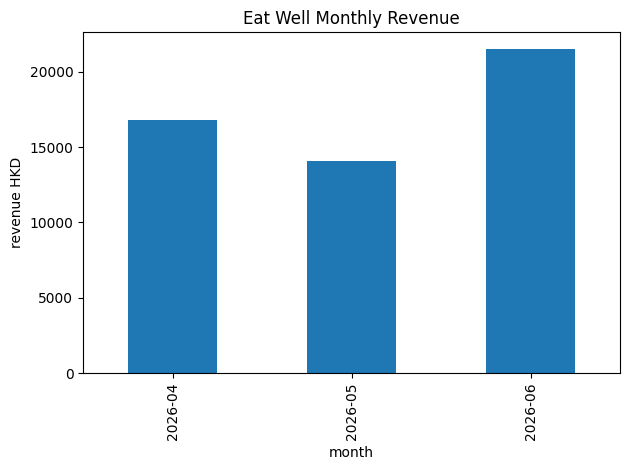

In [17]:
import matplotlib.pyplot as plt

monthly_revenue.plot(
    x="month",
    y="revenue",
    kind="bar",
    legend=False,
    title="Eat Well Monthly Revenue"
)

plt.xlabel("month")
plt.ylabel("revenue HKD")
plt.tight_layout()
plt.savefig("eatwell_monthly_revenue.png")
plt.show()

## Business Summary

1. Best-selling category: Shellfish appears to be an important category because it contains high-value products such as lobster, scallop, oyster, and tiger prawn.

2. Highest revenue product: The product ranking table helps identify which seafood product generated the most total revenue.

3. Strongest customer type: The customer type summary shows whether Restaurant, Retail, or Online customers contributed the highest revenue.

4. Suggested business action: Eat Well should focus on high-revenue seafood categories and develop targeted packages for the strongest customer type.

5. Next step: Add cost, supplier, and gross profit columns to make the analysis closer to real business decision-making.